## Sección 1 - Configuración inicial del entorno

In [ ]:
# Configuración inicial - Clasificación 2D

import os
import random
import warnings
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    recall_score,
    precision_score,
    roc_auc_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

warnings.filterwarnings("ignore")

# Detectar entorno
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Reproducibilidad
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Generador shuffle DataLoader
g_seed = torch.Generator()
g_seed.manual_seed(RANDOM_SEED)

def seed_worker(worker_id):
    worker_seed = RANDOM_SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

# Rutas principales
PROJECT_ROOT = "/content/drive/MyDrive/Proyecto imagenes y vision"

SLICES_ROOT = os.path.join(PROJECT_ROOT, "OASIS_2D_Slices")
AUGMENTED_CSV_PATH = os.path.join(SLICES_ROOT, "slices_augmented_128_index.csv")
REAL_CSV_PATH = os.path.join(SLICES_ROOT, "slices_real_128_index.csv")

OUTPUT_DIR = os.path.join(SLICES_ROOT, "classification_2d_outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Configuración de clasificación
IMG_SIZE = 128
BATCH_SIZE = 32
NUM_CLASSES = 2

# Umbral por defecto para cómputo de métricas
BCE_THRESHOLD = 0.5

# Clave de agregación a nivel de sujeto
SUBJECT_KEY = "subject_base"

# Rejilla de búsqueda de umbral óptimo
THRESHOLD_GRID = np.arange(0.10, 0.91, 0.05)

label_to_idx = {
    "sano": 0,
    "vmd": 1
}

idx_to_label = {
    0: "sano",
    1: "vmd"
}

print("Configuración cargada.")
print(f"IN_COLAB           : {IN_COLAB}")
print(f"Dispositivo        : {device}")
print(f"PyTorch            : {torch.__version__}")
print(f"PROJECT_ROOT       : {PROJECT_ROOT}")
print(f"AUGMENTED_CSV_PATH : {AUGMENTED_CSV_PATH}")
print(f"REAL_CSV_PATH      : {REAL_CSV_PATH}")
print(f"OUTPUT_DIR         : {OUTPUT_DIR}")
print(f"SUBJECT_KEY        : {SUBJECT_KEY}")
print(f"BCE_THRESHOLD      : {BCE_THRESHOLD}")

Mounted at /content/drive
Configuración cargada.
IN_COLAB           : True
Dispositivo        : cpu
PyTorch            : 2.10.0+cpu
PROJECT_ROOT       : /content/drive/MyDrive/Proyecto imagenes y vision
AUGMENTED_CSV_PATH : /content/drive/MyDrive/Proyecto imagenes y vision/OASIS_2D_Slices/slices_augmented_128_index.csv
REAL_CSV_PATH      : /content/drive/MyDrive/Proyecto imagenes y vision/OASIS_2D_Slices/slices_real_128_index.csv
OUTPUT_DIR         : /content/drive/MyDrive/Proyecto imagenes y vision/OASIS_2D_Slices/classification_2d_outputs
SUBJECT_KEY        : subject_base
BCE_THRESHOLD      : 0.5


## Sección 2 - Carga, validación y definición de escenarios experimentales

In [ ]:
# Cargar índices de slices reales y aumentados

assert os.path.exists(AUGMENTED_CSV_PATH), f"No existe: {AUGMENTED_CSV_PATH}"
assert os.path.exists(REAL_CSV_PATH), f"No existe: {REAL_CSV_PATH}"

augmented_df = pd.read_csv(AUGMENTED_CSV_PATH)
real_df = pd.read_csv(REAL_CSV_PATH)

print("augmented_df:", augmented_df.shape)
print("real_df:", real_df.shape)

display(augmented_df.head())

print("\nDistribución aumentada por split, label y source:")
display(
    pd.crosstab(
        [augmented_df["split"], augmented_df["label"]],
        augmented_df["source"],
        margins=True
    )
)

print("\nDistribución real por split y label:")
display(
    pd.crosstab(
        real_df["split"],
        real_df["label"],
        margins=True
    )
)

augmented_df: (2500, 9)
real_df: (2050, 9)


,subject_base,ID,CDR,label,label_idx,split,slice_idx,image_path,source
0,OAS1_0033,OAS1_0033_MR1,0.0,sano,0,train,50,/content/drive/MyDrive/Proyecto imagenes y vis...,real
1,OAS1_0033,OAS1_0033_MR1,0.0,sano,0,train,55,/content/drive/MyDrive/Proyecto imagenes y vis...,real
2,OAS1_0033,OAS1_0033_MR1,0.0,sano,0,train,60,/content/drive/MyDrive/Proyecto imagenes y vis...,real
3,OAS1_0033,OAS1_0033_MR1,0.0,sano,0,train,65,/content/drive/MyDrive/Proyecto imagenes y vis...,real
4,OAS1_0033,OAS1_0033_MR1,0.0,sano,0,train,70,/content/drive/MyDrive/Proyecto imagenes y vis...,real



Distribución aumentada por split, label y source:


source       real  synthetic_dcgan   All
split label                             
test  sano    210                0   210
      vmd     100                0   100
train sano    940                0   940
      vmd     490              450   940
val   sano    200                0   200
      vmd     110                0   110
All          2050              450  2500


Distribución real por split y label:


label,sano,vmd,All
split,,,
test,210,100,310
train,940,490,1430
val,200,110,310
All,1350,700,2050


In [ ]:
# Validaciones básicas del dataset

required_cols = [
    "subject_base",
    "ID",
    "CDR",
    "label",
    "label_idx",
    "split",
    "slice_idx",
    "image_path",
    "source"
]

for df_name, df in [("real_df", real_df), ("augmented_df", augmented_df)]:
    missing_cols = [col for col in required_cols if col not in df.columns]
    assert len(missing_cols) == 0, f"{df_name} no tiene columnas: {missing_cols}"

# Normalizar texto
for df in [real_df, augmented_df]:
    df["label"] = df["label"].astype(str).str.lower().str.strip()
    df["split"] = df["split"].astype(str).str.lower().str.strip()
    df["source"] = df["source"].astype(str).str.lower().str.strip()
    df["image_path"] = df["image_path"].astype(str)

# Validar splits
expected_splits = {"train", "val", "test"}

assert set(real_df["split"].unique()).issubset(expected_splits)
assert set(augmented_df["split"].unique()).issubset(expected_splits)

# Validar rutas
missing_real_paths = real_df[~real_df["image_path"].apply(os.path.exists)]
missing_aug_paths = augmented_df[~augmented_df["image_path"].apply(os.path.exists)]

print("Rutas reales faltantes:", len(missing_real_paths))
print("Rutas aumentadas faltantes:", len(missing_aug_paths))

assert len(missing_real_paths) == 0, "Hay imágenes reales que no existen."
assert len(missing_aug_paths) == 0, "Hay imágenes aumentadas que no existen."

# Validar que val/test no tengan sintéticos
val_test_aug = augmented_df[augmented_df["split"].isin(["val", "test"])]
assert (val_test_aug["source"] == "real").all(), "Hay sintéticos en val/test."

# Validar que sintéticos solo estén en train
synthetic_rows = augmented_df[augmented_df["source"] != "real"]
if len(synthetic_rows) > 0:
    assert set(synthetic_rows["split"].unique()) == {"train"}, "Hay sintéticos fuera de train."

# Validadar que ningún sujeto en más de un split
overlap_real = (
    real_df.groupby("subject_base")["split"].nunique().loc[lambda s: s > 1]
)
assert overlap_real.empty, (
    f"ERROR: {len(overlap_real)} sujeto(s) reales en más de un split. "
    f"Sujetos con leakage: {overlap_real.index.tolist()[:5]}..."
)

# Validar que sujetos reales no se mezclan entre splits
overlap_aug_real = (
    augmented_df[augmented_df["source"] == "real"]
    .groupby("subject_base")["split"].nunique().loc[lambda s: s > 1]
)
assert overlap_aug_real.empty, (
    f"ERROR: {len(overlap_aug_real)} sujeto(s) reales en más de un split en augmented_df."
)

# Validar que subject_base de sintéticos no colisiona con sujetos reales
real_subject_bases = set(real_df["subject_base"].unique())
synth_subject_bases = set(synthetic_rows["subject_base"].unique()) if len(synthetic_rows) > 0 else set()
collision = real_subject_bases & synth_subject_bases
assert len(collision) == 0, (
    f"ERROR: {len(collision)} subject_base(s) sintéticos colisionan con sujetos reales: "
)

print("Validaciones completadas correctamente.")
print(f"  - Sin sintéticos en val/test")
print(f"  - Sin overlap de sujetos entre splits (real_df y augmented_df)")
print(f"  - Sin colisión de subject_base entre reales y sintéticos")

Rutas reales faltantes: 0
Rutas aumentadas faltantes: 0
Validaciones completadas correctamente.
  - Sin sintéticos en val/test
  - Sin overlap de sujetos entre splits (real_df y augmented_df)
  - Sin colisión de subject_base entre reales y sintéticos


In [ ]:
# Construir dataframes para los tres escenarios

#   - baseline_real   : solo slices reales, sin aug
#   - traditional_aug : solo slices reales, con aug online en train
#   - dcgan_aug       : slices reales + sintéticos DCGAN


# 1. Baseline
baseline_train_df = real_df[real_df["split"] == "train"].copy()
baseline_val_df   = real_df[real_df["split"] == "val"].copy()
baseline_test_df  = real_df[real_df["split"] == "test"].copy()

# 2. Aumentación tradicional
traditional_train_df = baseline_train_df.copy()
traditional_val_df   = baseline_val_df.copy()
traditional_test_df  = baseline_test_df.copy()

# 3. DCGAN
real_train    = augmented_df[(augmented_df["split"] == "train") & (augmented_df["source"] == "real")]
synthetic_all = augmented_df[(augmented_df["split"] == "train") & (augmented_df["source"] != "real")]

n_real_sano = (real_train["label"] == "sano").sum()
n_real_vmd  = (real_train["label"] == "vmd").sum()

n_target_synth = max(0, n_real_sano - n_real_vmd)
n_synth_use    = min(n_target_synth, len(synthetic_all))

synthetic_sampled = synthetic_all.sample(
    n=n_synth_use,
    random_state=RANDOM_SEED
)

dcgan_train_df = pd.concat([real_train, synthetic_sampled]).reset_index(drop=True)
dcgan_val_df   = real_df[real_df["split"] == "val"].copy()
dcgan_test_df  = real_df[real_df["split"] == "test"].copy()

# Validaciones
assert (baseline_val_df["source"]   == "real").all()
assert (baseline_test_df["source"]  == "real").all()
assert (dcgan_val_df["source"]      == "real").all()
assert (dcgan_test_df["source"]     == "real").all()

# Resumen
print("Baseline:")
print("  Train:", baseline_train_df.shape)
print("  Val  :", baseline_val_df.shape)
print("  Test :", baseline_test_df.shape)

print("\nTraditional Aug:")
print("  Train:", traditional_train_df.shape)

print(f"\nDCGAN Aug (objetivo: balance simétrico sano:vmd ≈ 1:1):")
print(f"  Slices reales sano       : {n_real_sano}")
print(f"  Slices reales vmd        : {n_real_vmd}")
print(f"  Sintéticos disponibles   : {len(synthetic_all)}")
print(f"  Sintéticos incluidos     : {n_synth_use}")
print(f"  Train final shape        : {dcgan_train_df.shape}")

print("\nDistribución baseline train:")
display(pd.crosstab(baseline_train_df["label"], baseline_train_df["source"], margins=True))

print("\nDistribución DCGAN train:")
display(pd.crosstab(dcgan_train_df["label"], dcgan_train_df["source"], margins=True))

print("\nDistribución real val/test:")
display(pd.crosstab(real_df["split"], real_df["label"], margins=True))

Baseline:
  Train: (1430, 9)
  Val  : (310, 9)
  Test : (310, 9)

Traditional Aug:
  Train: (1430, 9)

DCGAN Aug (objetivo: balance simétrico sano:vmd ≈ 1:1):
  Slices reales sano       : 940
  Slices reales vmd        : 490
  Sintéticos disponibles   : 450
  Sintéticos incluidos     : 450
  Train final shape        : (1880, 9)

Distribución baseline train:


source,real,All
label,,
sano,940,940
vmd,490,490
All,1430,1430



Distribución DCGAN train:


source,real,synthetic_dcgan,All
label,,,
sano,940,0,940
vmd,490,450,940
All,1430,450,1880



Distribución real val/test:


label,sano,vmd,All
split,,,
test,210,100,310
train,940,490,1430
val,200,110,310
All,1350,700,2050


## Sección 3 - Dataset, DataLoaders y verificación visual de datos

In [ ]:
# Dataset para clasificación 2D con modos de aumentación

class OASIS2DSlicesDataset(Dataset):
    def __init__(self, dataframe, img_size=128, augmentation_mode="none"):
        self.dataframe = dataframe.reset_index(drop=True)
        self.img_size = img_size
        self.augmentation_mode = augmentation_mode

        base_transforms = [
            transforms.Grayscale(num_output_channels=3),
            transforms.Resize((img_size, img_size)),
        ]

        if augmentation_mode == "traditional":
            aug_transforms = [
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.RandomRotation(degrees=5),
                transforms.RandomAffine(
                    degrees=0,
                    translate=(0.03, 0.03),
                ),
            ]
        elif augmentation_mode == "none":
            aug_transforms = []

        final_transforms = [
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ]

        self.transform = transforms.Compose(
            base_transforms + aug_transforms + final_transforms
        )

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        image_path = row["image_path"]
        label = int(row["label_idx"])

        image = Image.open(image_path).convert("L")
        image = self.transform(image)

        return {
            "image": image,
            "label": torch.tensor(label, dtype=torch.float32),
            "subject_id": row["ID"],
            "subject_base": row["subject_base"],
            "image_path": image_path
        }

In [ ]:
# Crear DataLoaders con modo de aumentación configurable

NUM_WORKERS = 2

def create_dataloaders(
    train_df,
    val_df,
    test_df,
    batch_size=32,
    img_size=128,
    train_augmentation_mode="none"
):
    train_dataset = OASIS2DSlicesDataset(
        dataframe=train_df,
        img_size=img_size,
        augmentation_mode=train_augmentation_mode
    )

    val_dataset = OASIS2DSlicesDataset(
        dataframe=val_df,
        img_size=img_size,
        augmentation_mode="none"
    )

    test_dataset = OASIS2DSlicesDataset(
        dataframe=test_df,
        img_size=img_size,
        augmentation_mode="none"
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        worker_init_fn=seed_worker,
        generator=g_seed
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        worker_init_fn=seed_worker
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        worker_init_fn=seed_worker
    )

    return train_loader, val_loader, test_loader


In [ ]:
# DataLoaders baseline, traditional augmentation y DCGAN augmentation

baseline_train_loader, baseline_val_loader, baseline_test_loader = create_dataloaders(
    baseline_train_df,
    baseline_val_df,
    baseline_test_df,
    batch_size=BATCH_SIZE,
    img_size=IMG_SIZE,
    train_augmentation_mode="none"
)

traditional_train_loader, traditional_val_loader, traditional_test_loader = create_dataloaders(
    traditional_train_df,
    traditional_val_df,
    traditional_test_df,
    batch_size=BATCH_SIZE,
    img_size=IMG_SIZE,
    train_augmentation_mode="traditional"
)

dcgan_train_loader, dcgan_val_loader, dcgan_test_loader = create_dataloaders(
    dcgan_train_df,
    dcgan_val_df,
    dcgan_test_df,
    batch_size=BATCH_SIZE,
    img_size=IMG_SIZE,
    train_augmentation_mode="none"
)

print("DataLoaders creados correctamente.")

print("\nBaseline:")
print("Train:", len(baseline_train_loader))
print("Val  :", len(baseline_val_loader))
print("Test :", len(baseline_test_loader))

print("\nTraditional Aug:")
print("Train:", len(traditional_train_loader))
print("Val  :", len(traditional_val_loader))
print("Test :", len(traditional_test_loader))

print("\nDCGAN Aug:")
print("Train:", len(dcgan_train_loader))
print("Val  :", len(dcgan_val_loader))
print("Test :", len(dcgan_test_loader))

DataLoaders creados correctamente.

Baseline:
Train: 45
Val  : 10
Test : 10

Traditional Aug:
Train: 45
Val  : 10
Test : 10

DCGAN Aug:
Train: 59
Val  : 10
Test : 10


In [ ]:
# Verificar un batch

batch = next(iter(dcgan_train_loader))

images = batch["image"]
labels = batch["label"]

print("Shape imágenes:", images.shape)
print("Shape labels:", labels.shape)
print("Primeras labels:", labels[:10])
print("Rango imágenes:", images.min().item(), images.max().item())

Shape imágenes: torch.Size([32, 3, 128, 128])
Shape labels: torch.Size([32])
Primeras labels: tensor([0., 1., 1., 0., 0., 1., 1., 1., 0., 0.])
Rango imágenes: -2.1179039478302 2.640000104904175


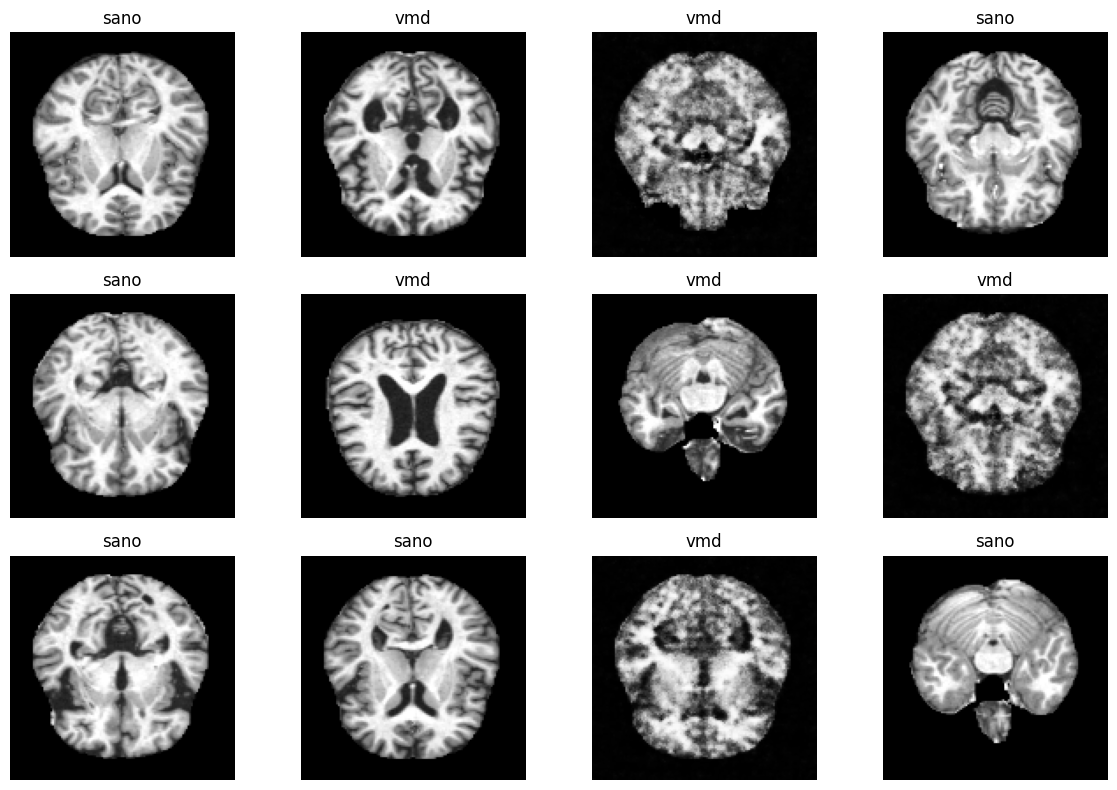

In [ ]:
# Visualizar imágenes del batch

def denormalize_image(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    img = img_tensor.cpu() * std + mean
    img = img.clamp(0, 1)

    return img


plt.figure(figsize=(12, 8))

for i in range(12):
    img = denormalize_image(images[i])
    img_np = img.permute(1, 2, 0).numpy()

    label_idx = int(labels[i].item())
    label_name = idx_to_label[label_idx]

    plt.subplot(3, 4, i + 1)
    plt.imshow(img_np)
    plt.title(label_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Sección 4 - Definición del clasificador y métricas diagnósticas

In [ ]:
# Crear ResNet18/ResNet34 para clasificación binaria

def create_resnet_binary(model_name="resnet18", pretrained=True):
    if model_name == "resnet18":
        weights = models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
        model = models.resnet18(weights=weights)

    elif model_name == "resnet34":
        weights = models.ResNet34_Weights.IMAGENET1K_V1 if pretrained else None
        model = models.resnet34(weights=weights)

    else:
        raise ValueError("model_name debe ser 'resnet18' o 'resnet34'")

    in_features = model.fc.in_features

    model.fc = nn.Linear(in_features, 1)

    return model

In [ ]:
# Probar salida del modelo

test_model = create_resnet_binary("resnet18", pretrained=True).to(device)

batch = next(iter(dcgan_train_loader))
images_test = batch["image"].to(device)

with torch.no_grad():
    logits = test_model(images_test)

print("Input shape:", images_test.shape)
print("Logits shape:", logits.shape)
print("Primeros logits:", logits[:5].squeeze())

del test_model
torch.cuda.empty_cache()

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 242MB/s]


Input shape: torch.Size([32, 3, 128, 128])
Logits shape: torch.Size([32, 1])
Primeros logits: tensor([-0.2777, -0.3616,  0.6359,  0.0701, -0.5612], device='cuda:0')


In [ ]:
# Métricas

def compute_binary_metrics(y_true, y_pred, y_prob=None):
    """
    Calcula el protocolo completo de métricas diagnósticas.
    'specificity' = recall de la clase sano (pos_label=0).
    """
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)

    metrics = {}

    metrics["accuracy"]          = accuracy_score(y_true, y_pred)
    metrics["balanced_accuracy"] = balanced_accuracy_score(y_true, y_pred)
    metrics["f1_macro"]          = f1_score(y_true, y_pred, average="macro", zero_division=0)
    metrics["f1_vmd"]            = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    metrics["precision_vmd"]     = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    metrics["recall_vmd"]        = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    metrics["specificity"]       = recall_score(y_true, y_pred, pos_label=0, zero_division=0)
    metrics["recall_sano"]       = metrics["specificity"]  # alias para compatibilidad

    # MCC
    if len(np.unique(y_true)) == 2 and len(np.unique(y_pred)) >= 1:
        metrics["mcc"] = matthews_corrcoef(y_true, y_pred)
    else:
        metrics["mcc"] = np.nan

    # ROC-AUC
    if y_prob is not None and len(np.unique(y_true)) == 2:
        try:
            metrics["auc"] = roc_auc_score(y_true, np.asarray(y_prob))
        except ValueError:
            metrics["auc"] = np.nan
    else:
        metrics["auc"] = np.nan

    return metrics


def print_metrics(metrics, prefix=""):
    print(f"{prefix}Loss              : {metrics.get('loss', float('nan')):.4f}")
    print(f"{prefix}Accuracy          : {metrics['accuracy']:.4f}")
    print(f"{prefix}Balanced Accuracy : {metrics['balanced_accuracy']:.4f}")
    print(f"{prefix}F1 Macro          : {metrics['f1_macro']:.4f}")
    print(f"{prefix}F1 VMD            : {metrics['f1_vmd']:.4f}")
    print(f"{prefix}Precision VMD     : {metrics['precision_vmd']:.4f}")
    print(f"{prefix}Recall VMD        : {metrics['recall_vmd']:.4f}")
    print(f"{prefix}Specificity       : {metrics['specificity']:.4f}")
    print(f"{prefix}MCC               : {metrics['mcc']:.4f}")
    print(f"{prefix}AUC               : {metrics['auc']:.4f}")


In [ ]:
# Entrenamiento de una época

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_labels = []
    all_probs = []

    for batch in dataloader:
        images = batch["image"].to(device)
        labels = batch["label"].to(device).view(-1, 1)

        optimizer.zero_grad()

        logits = model(images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        probs = torch.sigmoid(logits).detach().cpu().numpy().reshape(-1)
        labels_np = labels.detach().cpu().numpy().reshape(-1)

        all_probs.extend(probs)
        all_labels.extend(labels_np)

    epoch_loss = running_loss / len(dataloader.dataset)

    all_labels = np.array(all_labels).astype(int)
    all_probs = np.array(all_probs)
    all_preds = (all_probs >= 0.5).astype(int)

    metrics = compute_binary_metrics(all_labels, all_preds, all_probs)
    metrics["loss"] = epoch_loss

    return epoch_loss, metrics


In [ ]:
# Evaluación por slice

def evaluate_by_slice(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_labels = []
    all_probs = []
    all_subjects = []
    all_subject_bases = []
    all_paths = []

    with torch.no_grad():
        for batch in dataloader:
            images = batch["image"].to(device)
            labels = batch["label"].to(device).view(-1, 1)

            logits = model(images)
            loss = criterion(logits, labels)

            running_loss += loss.item() * images.size(0)

            probs = torch.sigmoid(logits).detach().cpu().numpy().reshape(-1)
            labels_np = labels.detach().cpu().numpy().reshape(-1)

            all_probs.extend(probs)
            all_labels.extend(labels_np)
            all_subjects.extend(batch["subject_id"])
            all_subject_bases.extend(batch["subject_base"])
            all_paths.extend(batch["image_path"])

    epoch_loss = running_loss / len(dataloader.dataset)

    all_labels = np.array(all_labels).astype(int)
    all_probs = np.array(all_probs)
    all_preds = (all_probs >= 0.5).astype(int)

    metrics = compute_binary_metrics(all_labels, all_preds, all_probs)
    metrics["loss"] = epoch_loss

    predictions_df = pd.DataFrame({
        "subject_id": all_subjects,
        "subject_base": all_subject_bases,
        "image_path": all_paths,
        "label": all_labels,
        "prob_vmd": all_probs,
        "pred": all_preds
    })

    return epoch_loss, metrics, predictions_df


In [ ]:
# Evaluación por sujeto

def aggregate_by_subject(predictions_df, subject_key=SUBJECT_KEY):
    """
    Agrupa los cortes por sujeto y promedia las probabilidades (soft voting).
    """
    label_consistency = predictions_df.groupby(subject_key)["label"].nunique()
    inconsistent = label_consistency[label_consistency > 1]
    assert inconsistent.empty, (
        f"ERROR: {len(inconsistent)} sujeto(s) con más de una etiqueta bajo "
        f"la clave '{subject_key}'. La clave de agregación es incorrecta."
    )

    subject_df = (
        predictions_df
        .groupby(subject_key)
        .agg(
            label=("label", "first"),
            prob_vmd=("prob_vmd", "mean"),
            n_slices=("prob_vmd", "count")
        )
        .reset_index()
    )
    return subject_df


def evaluate_by_subject(predictions_df, threshold=0.5, subject_key=SUBJECT_KEY,
                        subject_loss=None):
    """
    Evaluación a nivel de sujeto. Aplica el umbral dado sobre la
    probabilidad promediada por sujeto.
    """
    subject_df = aggregate_by_subject(predictions_df, subject_key=subject_key)
    subject_df["pred"] = (subject_df["prob_vmd"] >= threshold).astype(int)

    y_true = subject_df["label"].values.astype(int)
    y_pred = subject_df["pred"].values.astype(int)
    y_prob = subject_df["prob_vmd"].values

    metrics = compute_binary_metrics(y_true, y_pred, y_prob)
    if subject_loss is not None:
        metrics["loss"] = subject_loss

    return metrics, subject_df


def find_optimal_threshold(val_predictions_df, subject_key=SUBJECT_KEY,
                           threshold_grid=THRESHOLD_GRID):
    """
    Busca el umbral que maximiza el F1-macro a nivel de SUJETO sobre las
    predicciones agregadas de VALIDACIÓN. No usa el conjunto de test.
    Idéntico en lógica al notebook 3D.
    """
    val_subject_df = aggregate_by_subject(val_predictions_df, subject_key=subject_key)
    y_true = val_subject_df["label"].values.astype(int)
    probs  = val_subject_df["prob_vmd"].values

    best_thresh = 0.5
    best_f1 = -1.0
    for t in threshold_grid:
        preds_t = (probs >= t).astype(int)
        f1_t = f1_score(y_true, preds_t, average="macro", zero_division=0)
        if f1_t > best_f1:
            best_f1 = f1_t
            best_thresh = float(t)

    return best_thresh, best_f1


## Sección 5 - Funciones generales de entrenamiento y monitoreo

In [ ]:
# Función general de entrenamiento

def _count_labels_from_loader(train_loader):
    """
    Cuenta n_sano y n_vmd desde el dataframe interno del Dataset.
    """
    df = train_loader.dataset.dataframe
    real_df_only = df[df["source"] == "real"] if "source" in df.columns else df
    n_sano = int((real_df_only["label_idx"] == 0).sum())
    n_vmd  = int((real_df_only["label_idx"] == 1).sum())
    return n_sano, n_vmd


def train_model(
    model_name,
    train_loader,
    val_loader,
    experiment_name,
    num_epochs=35,
    learning_rate=1e-4,
    weight_decay=1e-4,
    patience=8
):
    model = create_resnet_binary(model_name=model_name, pretrained=True).to(device)

    n_sano, n_vmd = _count_labels_from_loader(train_loader)
    if n_vmd > 0:
        pw_value = n_sano / n_vmd
        pos_weight = torch.tensor([pw_value], dtype=torch.float32).to(device)
        print(f"pos_weight VMD: {pw_value:.4f}  (sano_real={n_sano}, vmd_real={n_vmd})")
    else:
        pos_weight = None
        print(f"pos_weight VMD: None  (vmd_real=0; sano_real={n_sano})")

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    optimizer = optim.AdamW([
        {"params": model.layer1.parameters(), "lr": learning_rate * 0.01},
        {"params": model.layer2.parameters(), "lr": learning_rate * 0.01},
        {"params": model.layer3.parameters(), "lr": learning_rate * 0.1},
        {"params": model.layer4.parameters(), "lr": learning_rate * 0.5},
        {"params": model.fc.parameters(),     "lr": learning_rate},
    ], weight_decay=weight_decay)

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=2
    )

    best_metric = -np.inf
    best_epoch = -1
    epochs_without_improvement = 0

    history = []

    best_model_path = os.path.join(
        OUTPUT_DIR,
        f"best_{experiment_name}_{model_name}.pth"
    )

    use_cuda = (device.type == "cuda")
    if use_cuda:
        torch.cuda.reset_peak_memory_stats(device)

    start_time = time.time()

    for epoch in range(num_epochs):
        epoch_start = time.time()

        train_loss, train_slice_metrics = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )

        val_loss, val_slice_metrics, val_preds_df = evaluate_by_slice(
            model, val_loader, criterion, device
        )

        epoch_thresh, _ = find_optimal_threshold(val_preds_df)

        val_subject_metrics, val_subject_df = evaluate_by_subject(
            val_preds_df,
            threshold=epoch_thresh,
            subject_loss=val_loss
        )

        current_metric = val_subject_metrics["f1_macro"]

        scheduler.step(current_metric)

        epoch_time = time.time() - epoch_start

        row = {
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_opt_threshold": epoch_thresh,
            "train_slice_bal_acc": train_slice_metrics["balanced_accuracy"],
            "train_slice_f1_macro": train_slice_metrics["f1_macro"],
            "train_slice_recall_vmd": train_slice_metrics["recall_vmd"],
            "val_slice_bal_acc": val_slice_metrics["balanced_accuracy"],
            "val_slice_f1_macro": val_slice_metrics["f1_macro"],
            "val_slice_recall_vmd": val_slice_metrics["recall_vmd"],
            "val_subject_bal_acc": val_subject_metrics["balanced_accuracy"],
            "val_subject_f1_macro": val_subject_metrics["f1_macro"],
            "val_subject_recall_vmd": val_subject_metrics["recall_vmd"],
            "val_subject_specificity": val_subject_metrics["specificity"],
            "val_subject_recall_sano": val_subject_metrics["recall_sano"],
            "val_subject_precision_vmd": val_subject_metrics["precision_vmd"],
            "val_subject_mcc": val_subject_metrics["mcc"],
            "val_subject_auc": val_subject_metrics["auc"],
            "lr": optimizer.param_groups[0]["lr"],
            "epoch_time_sec": epoch_time
        }

        history.append(row)

        print(
            f"Epoch [{epoch+1}/{num_epochs}] "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Thr: {epoch_thresh:.2f} | "
            f"Val Subj F1: {val_subject_metrics['f1_macro']:.4f} | "
            f"Val Subj BalAcc: {val_subject_metrics['balanced_accuracy']:.4f} | "
            f"Val Recall VMD: {val_subject_metrics['recall_vmd']:.4f} | "
            f"Val MCC: {val_subject_metrics['mcc']:.4f} | "
            f"Time: {epoch_time:.1f}s"
        )

        if current_metric > best_metric:
            best_metric = current_metric
            best_epoch = epoch + 1
            epochs_without_improvement = 0

            torch.save({
                "model_state_dict": model.state_dict(),
                "model_name": model_name,
                "experiment_name": experiment_name,
                "epoch": epoch + 1,
                "best_metric": best_metric,
                "best_val_threshold": epoch_thresh,
                "val_subject_metrics": val_subject_metrics,
                "val_slice_metrics": val_slice_metrics,
                "label_to_idx": label_to_idx,
                "idx_to_label": idx_to_label
            }, best_model_path)

            print(f"  Mejor modelo guardado: {best_model_path}")

        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"Early stopping en epoch {epoch+1}.")
            break

    total_time = time.time() - start_time
    peak_gpu_mem_gb = (torch.cuda.max_memory_allocated(device) / 1e9) if use_cuda else 0.0

    history_df = pd.DataFrame(history)
    mean_epoch_time = history_df["epoch_time_sec"].mean()

    history_path = os.path.join(
        OUTPUT_DIR,
        f"history_{experiment_name}_{model_name}.csv"
    )
    history_df.to_csv(history_path, index=False)

    cost_summary = {
        "experiment_name": experiment_name,
        "model_name": model_name,
        "total_time_min": total_time / 60.0,
        "mean_epoch_time_s": mean_epoch_time,
        "peak_gpu_mem_gb": peak_gpu_mem_gb,
        "epochs_trained": len(history_df),
        "best_epoch": best_epoch,
        "best_val_subject_f1_macro": best_metric
    }

    print("\nEntrenamiento finalizado.")
    print(f"Mejor epoch: {best_epoch}")
    print(f"Mejor Val Subject F1-macro: {best_metric:.4f}")
    print(f"Tiempo total: {total_time / 60:.2f} min")
    print(f"Tiempo medio por época: {mean_epoch_time:.1f} s")
    print(f"Pico de memoria GPU: {peak_gpu_mem_gb:.2f} GB")
    print(f"Historial guardado en: {history_path}")

    return model, history_df, best_model_path, cost_summary


In [ ]:
# Función para graficar historial

def plot_training_history(history_df, title="Historial de entrenamiento"):
    plt.figure(figsize=(12, 5))

    plt.plot(history_df["epoch"], history_df["train_loss"], label="Train loss")
    plt.plot(history_df["epoch"], history_df["val_loss"], label="Val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} - Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(12, 5))

    plt.plot(history_df["epoch"], history_df["val_subject_bal_acc"], label="Val subject balanced accuracy")
    plt.plot(history_df["epoch"], history_df["val_subject_f1_macro"], label="Val subject F1 macro")
    plt.plot(history_df["epoch"], history_df["val_subject_recall_vmd"], label="Val subject recall VMD")
    plt.plot(history_df["epoch"], history_df["val_subject_recall_sano"], label="Val subject recall sano")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.title(f"{title} - Métricas por sujeto")
    plt.legend()
    plt.grid(True)
    plt.show()

## Sección 6 - Entrenamiento y análisis de ResNet18

In [ ]:
# Entrenar ResNet18

(resnet18_baseline_model, resnet18_baseline_history,
 resnet18_baseline_path, resnet18_baseline_cost) = train_model(
    model_name="resnet18",
    train_loader=baseline_train_loader,
    val_loader=baseline_val_loader,
    experiment_name="baseline_real",
    num_epochs=20,
    learning_rate=1e-4,
    weight_decay=1e-4,
    patience=5
)

(resnet18_tradaug_model, resnet18_tradaug_history,
 resnet18_tradaug_path, resnet18_tradaug_cost) = train_model(
    model_name="resnet18",
    train_loader=traditional_train_loader,
    val_loader=traditional_val_loader,
    experiment_name="traditional_aug",
    num_epochs=20,
    learning_rate=1e-4,
    weight_decay=1e-4,
    patience=5
)

(resnet18_dcgan_model, resnet18_dcgan_history,
 resnet18_dcgan_path, resnet18_dcgan_cost) = train_model(
    model_name="resnet18",
    train_loader=dcgan_train_loader,
    val_loader=dcgan_val_loader,
    experiment_name="dcgan_aug",
    num_epochs=20,
    learning_rate=1e-4,
    weight_decay=1e-4,
    patience=5
)


pos_weight VMD: 1.9184  (sano_real=940, vmd_real=490)
Epoch [1/20] Train Loss: 0.8734 | Val Loss: 0.8342 | Thr: 0.50 | Val Subj F1: 0.7480 | Val Subj BalAcc: 0.7432 | Val Recall VMD: 0.6364 | Val MCC: 0.4978 | Time: 565.0s
  Mejor modelo guardado: /content/drive/MyDrive/Proyecto imagenes y vision/OASIS_2D_Slices/classification_2d_outputs/best_baseline_real_resnet18.pth
Epoch [2/20] Train Loss: 0.5843 | Val Loss: 0.8306 | Thr: 0.40 | Val Subj F1: 0.7961 | Val Subj BalAcc: 0.8091 | Val Recall VMD: 0.8182 | Val MCC: 0.5994 | Time: 3.7s
  Mejor modelo guardado: /content/drive/MyDrive/Proyecto imagenes y vision/OASIS_2D_Slices/classification_2d_outputs/best_baseline_real_resnet18.pth
Epoch [3/20] Train Loss: 0.3509 | Val Loss: 0.9581 | Thr: 0.30 | Val Subj F1: 0.8324 | Val Subj BalAcc: 0.8545 | Val Recall VMD: 0.9091 | Val MCC: 0.6817 | Time: 3.8s
  Mejor modelo guardado: /content/drive/MyDrive/Proyecto imagenes y vision/OASIS_2D_Slices/classification_2d_outputs/best_baseline_real_resnet18.

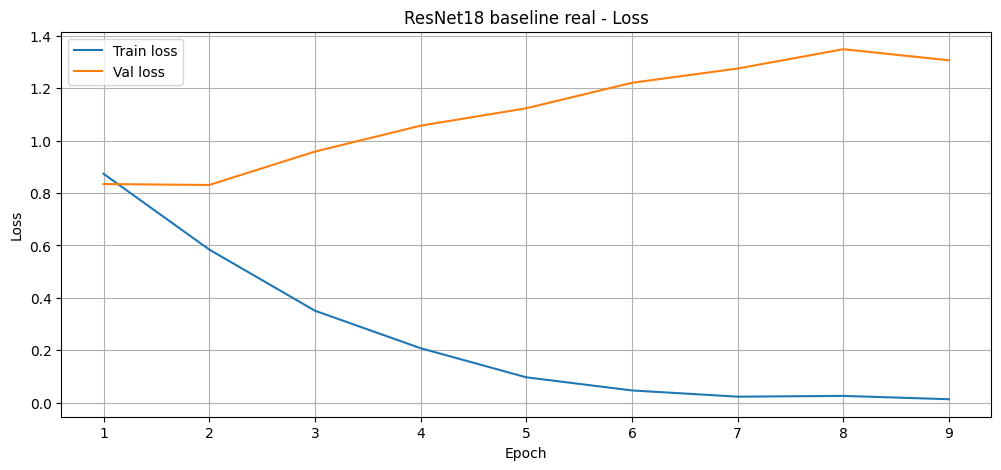

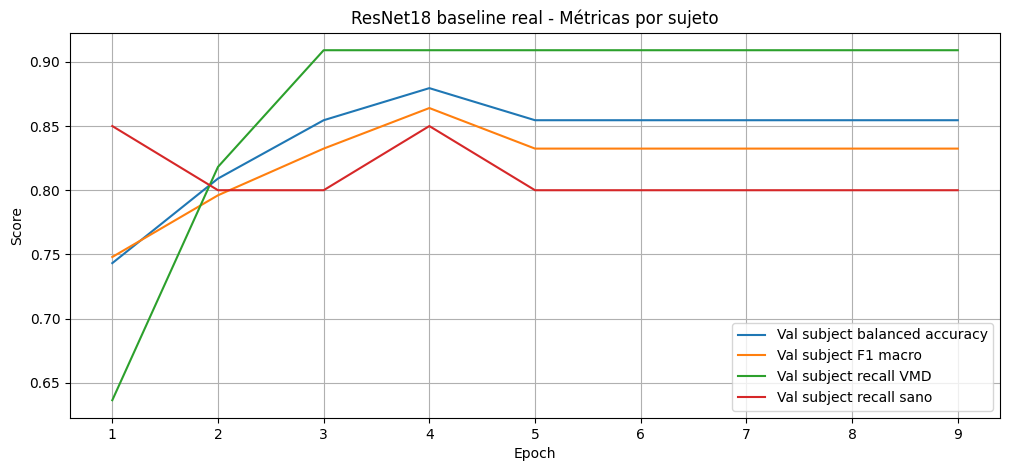

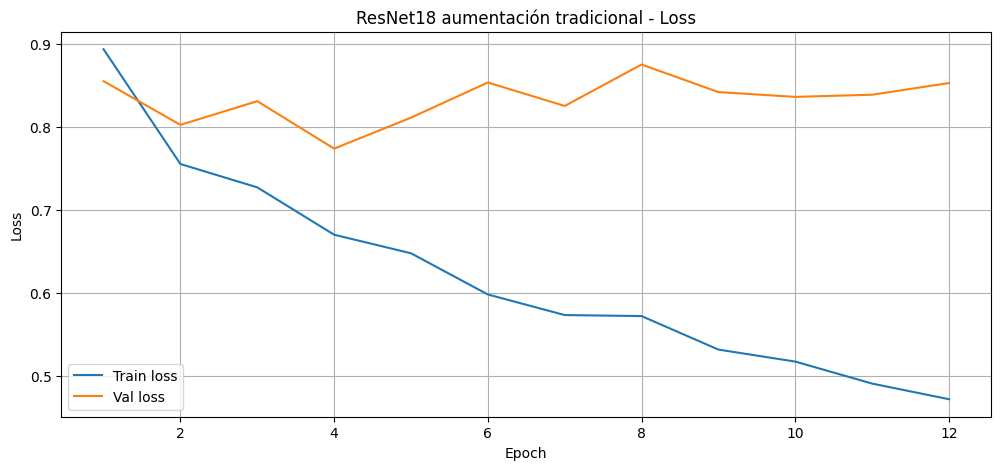

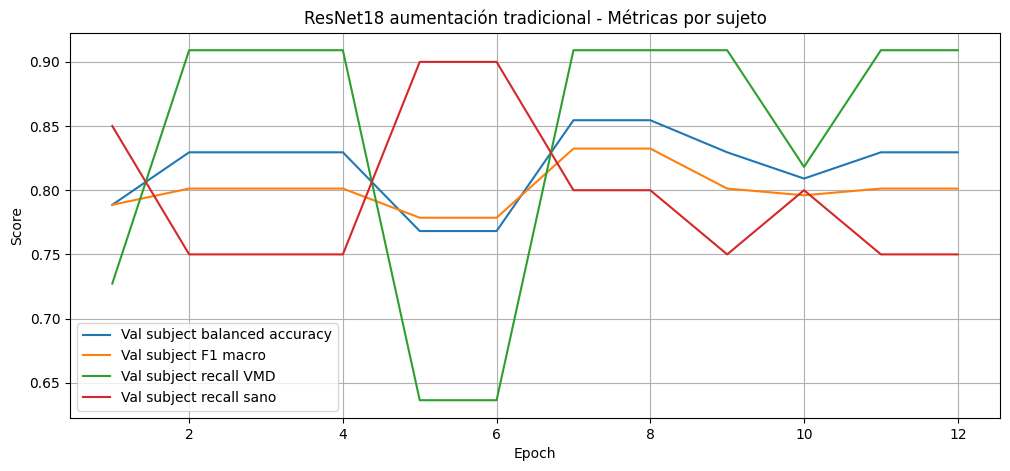

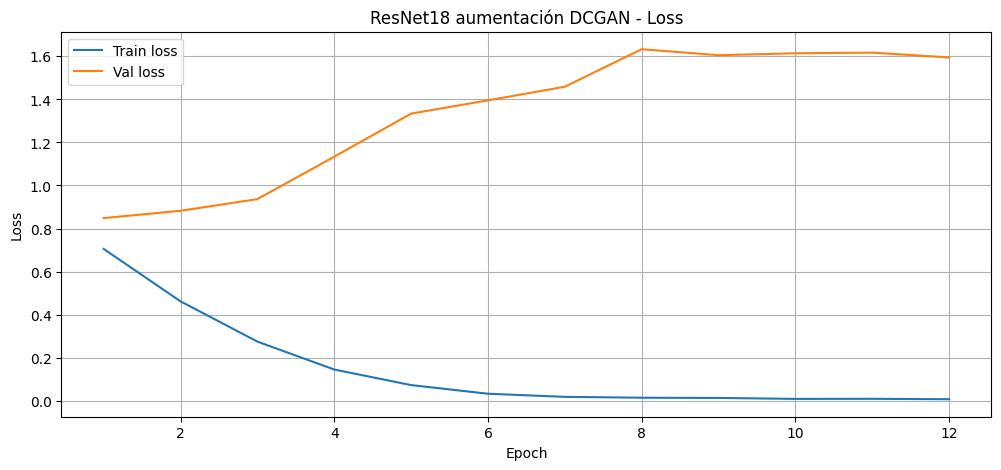

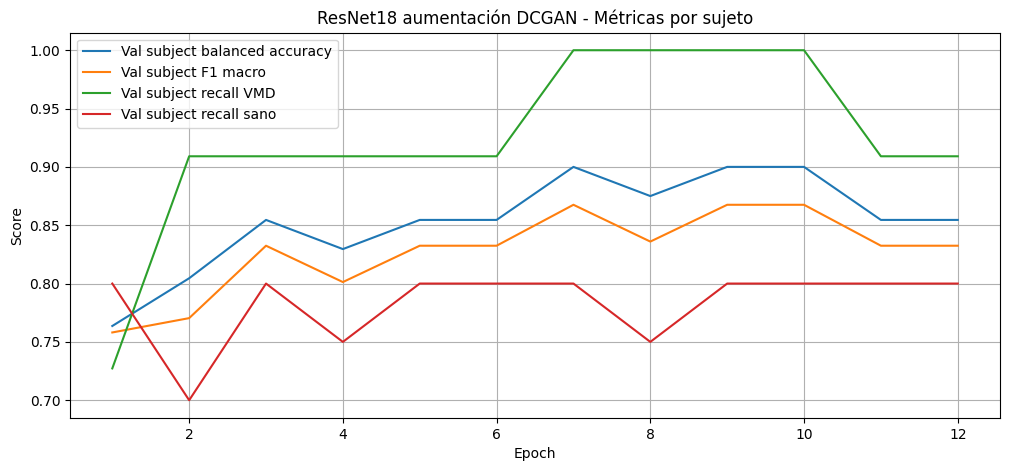

In [ ]:
# Historiales ResNet18

plot_training_history(
    resnet18_baseline_history,
    title="ResNet18 baseline real"
)

plot_training_history(
    resnet18_tradaug_history,
    title="ResNet18 aumentación tradicional"
)

plot_training_history(
    resnet18_dcgan_history,
    title="ResNet18 aumentación DCGAN"
)

In [ ]:
# Funciones para cargar mejor checkpoint y evaluar en test


def load_best_model(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

    model_name = checkpoint["model_name"]
    model = create_resnet_binary(model_name=model_name, pretrained=False).to(device)

    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    return model, checkpoint


def evaluate_checkpoint_on_test(checkpoint_path, val_loader, test_loader,
                                experiment_label, cost_summary=None,
                                subject_key=SUBJECT_KEY):
    """
    Paso 1: con el mejor checkpoint, se obtienen las predicciones por slice
            de VALIDACIÓN, se agregan a nivel de sujeto y se busca el umbral
            que maximiza el F1-macro de sujeto.
    Paso 2: ese umbral se aplica, sin recalibrar, sobre el conjunto de TEST,
            evaluado también a nivel de sujeto. Test NO interviene en la
            elección del umbral.
    """
    model, checkpoint = load_best_model(checkpoint_path)
    criterion = nn.BCEWithLogitsLoss()

    # Paso 1: umbral óptimo sobre VAL
    val_loss, val_slice_metrics, val_preds_df = evaluate_by_slice(
        model, val_loader, criterion, device
    )
    best_thresh, best_f1_val = find_optimal_threshold(
        val_preds_df, subject_key=subject_key
    )

    val_subject_metrics, _ = evaluate_by_subject(
        val_preds_df, threshold=best_thresh,
        subject_key=subject_key, subject_loss=val_loss
    )

    # Paso 2: evaluación en TEST con el umbral fijado
    test_loss, test_slice_metrics, test_preds_df = evaluate_by_slice(
        model, test_loader, criterion, device
    )
    test_subject_metrics, test_subject_df = evaluate_by_subject(
        test_preds_df, threshold=best_thresh,
        subject_key=subject_key, subject_loss=test_loss
    )

    print(f"{'=' * 60}")
    print(f"Resultados TEST - {experiment_label}")
    print(f"{'=' * 60}")
    print(f"Umbral óptimo: {best_thresh:.2f}  "
          f"(F1-macro val sujeto = {best_f1_val:.4f})")
    print(f"\nMétricas a nivel de SUJETO en TEST:")
    print_metrics(test_subject_metrics, prefix="  ")
    print(f"\n  Sujetos en test: {len(test_subject_df)}  | "
          f"cortes/sujeto min={test_subject_df['n_slices'].min()} "
          f"max={test_subject_df['n_slices'].max()}")

    # Guardar predicciones
    preds_path = os.path.join(
        OUTPUT_DIR, f"predictions_test_{experiment_label}.csv"
    )
    subject_preds_path = os.path.join(
        OUTPUT_DIR, f"predictions_test_subject_{experiment_label}.csv"
    )
    test_preds_df.to_csv(preds_path, index=False)
    test_subject_df.to_csv(subject_preds_path, index=False)

    print(f"\nPredicciones guardadas en:")
    print(f"  {preds_path}")
    print(f"  {subject_preds_path}")

    return {
        "experiment": experiment_label,
        "checkpoint_path": checkpoint_path,
        "optimal_threshold": best_thresh,
        "val_subject_metrics": val_subject_metrics,
        "test_loss": test_loss,
        "slice_metrics": test_slice_metrics,
        "subject_metrics": test_subject_metrics,
        "slice_predictions": test_preds_df,
        "subject_predictions": test_subject_df,
        "cost_summary": cost_summary
    }


In [ ]:
# Evaluación sobre VALIDACIÓN (ResNet18)


checkpoints_resnet18 = {
    "baseline_real":   os.path.join(OUTPUT_DIR, "best_baseline_real_resnet18.pth"),
    "traditional_aug": os.path.join(OUTPUT_DIR, "best_traditional_aug_resnet18.pth"),
    "dcgan_aug":       os.path.join(OUTPUT_DIR, "best_dcgan_aug_resnet18.pth"),
}

val_loaders_resnet18 = {
    "baseline_real":   baseline_val_loader,
    "traditional_aug": traditional_val_loader,
    "dcgan_aug":       dcgan_val_loader,
}

val_summary_rows_resnet18 = []

for exp_name, ckpt_path in checkpoints_resnet18.items():
    print(f"\n{'=' * 60}")
    print(f"Validación — ResNet18 / {exp_name}")
    print(f"{'=' * 60}")

    model, _ = load_best_model(ckpt_path)
    criterion = nn.BCEWithLogitsLoss()

    val_loss, val_slice_metrics, val_preds_df = evaluate_by_slice(
        model, val_loaders_resnet18[exp_name], criterion, device
    )

    best_thresh, best_f1_val = find_optimal_threshold(val_preds_df)

    val_subject_metrics, val_subject_df = evaluate_by_subject(
        val_preds_df,
        threshold=best_thresh,
        subject_loss=val_loss
    )

    print(f"Umbral óptimo: {best_thresh:.2f}  (F1-macro val sujeto = {best_f1_val:.4f})")
    print(f"\nMétricas a nivel de SUJETO en VALIDACIÓN:")
    print_metrics(val_subject_metrics, prefix="  ")
    print(f"\n  Sujetos en val: {len(val_subject_df)}  | "
          f"cortes/sujeto min={val_subject_df['n_slices'].min()} "
          f"max={val_subject_df['n_slices'].max()}")

    val_subject_df.to_csv(
        os.path.join(OUTPUT_DIR, f"val_subject_predictions_resnet18_{exp_name}.csv"),
        index=False
    )

    val_summary_rows_resnet18.append({
        "model":             "resnet18",
        "experiment":        exp_name,
        "optimal_threshold": best_thresh,
        "loss":              val_subject_metrics.get("loss", np.nan),
        "f1_macro":          val_subject_metrics["f1_macro"],
        "balanced_accuracy": val_subject_metrics["balanced_accuracy"],
        "recall_vmd":        val_subject_metrics["recall_vmd"],
        "precision_vmd":     val_subject_metrics["precision_vmd"],
        "specificity":       val_subject_metrics["specificity"],
        "auc":               val_subject_metrics["auc"],
        "mcc":               val_subject_metrics["mcc"],
    })

    del model
    torch.cuda.empty_cache()

val_summary_resnet18_df = pd.DataFrame(val_summary_rows_resnet18)
print("\n\nResumen VALIDACIÓN — ResNet18:")
display(val_summary_resnet18_df)
val_summary_resnet18_df.to_csv(os.path.join(OUTPUT_DIR, "val_summary_resnet18.csv"), index=False)


Validación — ResNet18 / baseline_real
Umbral óptimo: 0.35  (F1-macro val sujeto = 0.8640)

Métricas a nivel de SUJETO en VALIDACIÓN:
  Loss              : 0.6821
  Accuracy          : 0.8710
  Balanced Accuracy : 0.8795
  F1 Macro          : 0.8640
  F1 VMD            : 0.8333
  Precision VMD     : 0.7692
  Recall VMD        : 0.9091
  Specificity       : 0.8500
  MCC               : 0.7360
  AUC               : 0.8545

  Sujetos en val: 31  | cortes/sujeto min=10 max=10

Validación — ResNet18 / traditional_aug
Umbral óptimo: 0.45  (F1-macro val sujeto = 0.8324)

Métricas a nivel de SUJETO en VALIDACIÓN:
  Loss              : 0.5925
  Accuracy          : 0.8387
  Balanced Accuracy : 0.8545
  F1 Macro          : 0.8324
  F1 VMD            : 0.8000
  Precision VMD     : 0.7143
  Recall VMD        : 0.9091
  Specificity       : 0.8000
  MCC               : 0.6817
  AUC               : 0.8455

  Sujetos en val: 31  | cortes/sujeto min=10 max=10

Validación — ResNet18 / dcgan_aug
Umbral óp

,model,experiment,optimal_threshold,loss,f1_macro,balanced_accuracy,recall_vmd,precision_vmd,specificity,auc,mcc
0,resnet18,baseline_real,0.35,0.682133,0.864035,0.879545,0.909091,0.769231,0.85,0.854545,0.736033
1,resnet18,traditional_aug,0.45,0.592535,0.832432,0.854545,0.909091,0.714286,0.80,0.845455,0.681749
2,resnet18,dcgan_aug,0.25,0.939929,0.867521,0.900000,1.000000,0.733333,0.80,0.859091,0.765942


## Sección 7 - Entrenamiento y análisis de ResNet34

In [ ]:
# Entrenar ResNet34

(resnet34_baseline_model, resnet34_baseline_history,
 resnet34_baseline_path, resnet34_baseline_cost) = train_model(
    model_name="resnet34",
    train_loader=baseline_train_loader,
    val_loader=baseline_val_loader,
    experiment_name="baseline_real",
    num_epochs=20,
    learning_rate=1e-4,
    weight_decay=1e-4,
    patience=5
)

(resnet34_tradaug_model, resnet34_tradaug_history,
 resnet34_tradaug_path, resnet34_tradaug_cost) = train_model(
    model_name="resnet34",
    train_loader=traditional_train_loader,
    val_loader=traditional_val_loader,
    experiment_name="traditional_aug",
    num_epochs=20,
    learning_rate=1e-4,
    weight_decay=1e-4,
    patience=5
)

(resnet34_dcgan_model, resnet34_dcgan_history,
 resnet34_dcgan_path, resnet34_dcgan_cost) = train_model(
    model_name="resnet34",
    train_loader=dcgan_train_loader,
    val_loader=dcgan_val_loader,
    experiment_name="dcgan_aug",
    num_epochs=20,
    learning_rate=1e-4,
    weight_decay=1e-4,
    patience=5
)


Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 257MB/s]


pos_weight VMD: 1.9184  (sano_real=940, vmd_real=490)
Epoch [1/20] Train Loss: 0.8826 | Val Loss: 1.0186 | Thr: 0.30 | Val Subj F1: 0.7961 | Val Subj BalAcc: 0.8091 | Val Recall VMD: 0.8182 | Val MCC: 0.5994 | Time: 4.1s
  Mejor modelo guardado: /content/drive/MyDrive/Proyecto imagenes y vision/OASIS_2D_Slices/classification_2d_outputs/best_baseline_real_resnet34.pth
Epoch [2/20] Train Loss: 0.4969 | Val Loss: 1.0843 | Thr: 0.30 | Val Subj F1: 0.8324 | Val Subj BalAcc: 0.8545 | Val Recall VMD: 0.9091 | Val MCC: 0.6817 | Time: 4.1s
  Mejor modelo guardado: /content/drive/MyDrive/Proyecto imagenes y vision/OASIS_2D_Slices/classification_2d_outputs/best_baseline_real_resnet34.pth
Epoch [3/20] Train Loss: 0.2555 | Val Loss: 1.1226 | Thr: 0.30 | Val Subj F1: 0.8324 | Val Subj BalAcc: 0.8545 | Val Recall VMD: 0.9091 | Val MCC: 0.6817 | Time: 4.4s
Epoch [4/20] Train Loss: 0.1151 | Val Loss: 1.3629 | Thr: 0.25 | Val Subj F1: 0.8324 | Val Subj BalAcc: 0.8545 | Val Recall VMD: 0.9091 | Val MCC: 

In [ ]:
# Evaluación sobre VALIDACIÓN (ResNet34)

checkpoints_resnet34 = {
    "baseline_real":   os.path.join(OUTPUT_DIR, "best_baseline_real_resnet34.pth"),
    "traditional_aug": os.path.join(OUTPUT_DIR, "best_traditional_aug_resnet34.pth"),
    "dcgan_aug":       os.path.join(OUTPUT_DIR, "best_dcgan_aug_resnet34.pth"),
}

val_loaders_resnet34 = {
    "baseline_real":   baseline_val_loader,
    "traditional_aug": traditional_val_loader,
    "dcgan_aug":       dcgan_val_loader,
}

val_summary_rows_resnet34 = []

for exp_name, ckpt_path in checkpoints_resnet34.items():
    print(f"\n{'=' * 60}")
    print(f"Validación — ResNet34 / {exp_name}")
    print(f"{'=' * 60}")

    model, _ = load_best_model(ckpt_path)
    criterion = nn.BCEWithLogitsLoss()

    val_loss, val_slice_metrics, val_preds_df = evaluate_by_slice(
        model, val_loaders_resnet34[exp_name], criterion, device
    )

    best_thresh, best_f1_val = find_optimal_threshold(val_preds_df)

    val_subject_metrics, val_subject_df = evaluate_by_subject(
        val_preds_df,
        threshold=best_thresh,
        subject_loss=val_loss
    )

    print(f"Umbral óptimo: {best_thresh:.2f}  (F1-macro val sujeto = {best_f1_val:.4f})")
    print(f"\nMétricas a nivel de SUJETO en VALIDACIÓN:")
    print_metrics(val_subject_metrics, prefix="  ")
    print(f"\n  Sujetos en val: {len(val_subject_df)}  | "
          f"cortes/sujeto min={val_subject_df['n_slices'].min()} "
          f"max={val_subject_df['n_slices'].max()}")

    val_subject_df.to_csv(
        os.path.join(OUTPUT_DIR, f"val_subject_predictions_resnet34_{exp_name}.csv"),
        index=False
    )

    val_summary_rows_resnet34.append({
        "model":             "resnet34",
        "experiment":        exp_name,
        "optimal_threshold": best_thresh,
        "loss":              val_subject_metrics.get("loss", np.nan),
        "f1_macro":          val_subject_metrics["f1_macro"],
        "balanced_accuracy": val_subject_metrics["balanced_accuracy"],
        "recall_vmd":        val_subject_metrics["recall_vmd"],
        "precision_vmd":     val_subject_metrics["precision_vmd"],
        "specificity":       val_subject_metrics["specificity"],
        "auc":               val_subject_metrics["auc"],
        "mcc":               val_subject_metrics["mcc"],
    })

    del model
    torch.cuda.empty_cache()

val_summary_resnet34_df = pd.DataFrame(val_summary_rows_resnet34)
print("\n\nResumen VALIDACIÓN — ResNet34:")
display(val_summary_resnet34_df)
val_summary_resnet34_df.to_csv(os.path.join(OUTPUT_DIR, "val_summary_resnet34.csv"), index=False)

#  Tabla con todos los modelos
val_all_summary_df = pd.concat(
    [val_summary_resnet18_df, val_summary_resnet34_df],
    ignore_index=True
)
print("\n\nResumen VALIDACIÓN — todos los modelos:")
display(val_all_summary_df)
val_all_summary_df.to_csv(os.path.join(OUTPUT_DIR, "val_summary_all.csv"), index=False)



Validación — ResNet34 / baseline_real
Umbral óptimo: 0.30  (F1-macro val sujeto = 0.8324)

Métricas a nivel de SUJETO en VALIDACIÓN:
  Loss              : 0.6952
  Accuracy          : 0.8387
  Balanced Accuracy : 0.8545
  F1 Macro          : 0.8324
  F1 VMD            : 0.8000
  Precision VMD     : 0.7143
  Recall VMD        : 0.9091
  Specificity       : 0.8000
  MCC               : 0.6817
  AUC               : 0.8182

  Sujetos en val: 31  | cortes/sujeto min=10 max=10

Validación — ResNet34 / traditional_aug
Umbral óptimo: 0.30  (F1-macro val sujeto = 0.8324)

Métricas a nivel de SUJETO en VALIDACIÓN:
  Loss              : 0.6177
  Accuracy          : 0.8387
  Balanced Accuracy : 0.8545
  F1 Macro          : 0.8324
  F1 VMD            : 0.8000
  Precision VMD     : 0.7143
  Recall VMD        : 0.9091
  Specificity       : 0.8000
  MCC               : 0.6817
  AUC               : 0.8227

  Sujetos en val: 31  | cortes/sujeto min=10 max=10

Validación — ResNet34 / dcgan_aug
Umbral óp

,model,experiment,optimal_threshold,loss,f1_macro,balanced_accuracy,recall_vmd,precision_vmd,specificity,auc,mcc
0,resnet34,baseline_real,0.30,0.695203,0.832432,0.854545,0.909091,0.714286,0.8,0.818182,0.681749
1,resnet34,traditional_aug,0.30,0.617715,0.832432,0.854545,0.909091,0.714286,0.8,0.822727,0.681749
2,resnet34,dcgan_aug,0.25,0.963403,0.867521,0.900000,1.000000,0.733333,0.8,0.840909,0.765942




Resumen VALIDACIÓN — todos los modelos:


,model,experiment,optimal_threshold,loss,f1_macro,balanced_accuracy,recall_vmd,precision_vmd,specificity,auc,mcc
0,resnet18,baseline_real,0.35,0.682133,0.864035,0.879545,0.909091,0.769231,0.85,0.854545,0.736033
1,resnet18,traditional_aug,0.45,0.592535,0.832432,0.854545,0.909091,0.714286,0.80,0.845455,0.681749
2,resnet18,dcgan_aug,0.25,0.939929,0.867521,0.900000,1.000000,0.733333,0.80,0.859091,0.765942
3,resnet34,baseline_real,0.30,0.695203,0.832432,0.854545,0.909091,0.714286,0.80,0.818182,0.681749
4,resnet34,traditional_aug,0.30,0.617715,0.832432,0.854545,0.909091,0.714286,0.80,0.822727,0.681749
5,resnet34,dcgan_aug,0.25,0.963403,0.867521,0.900000,1.000000,0.733333,0.80,0.840909,0.765942


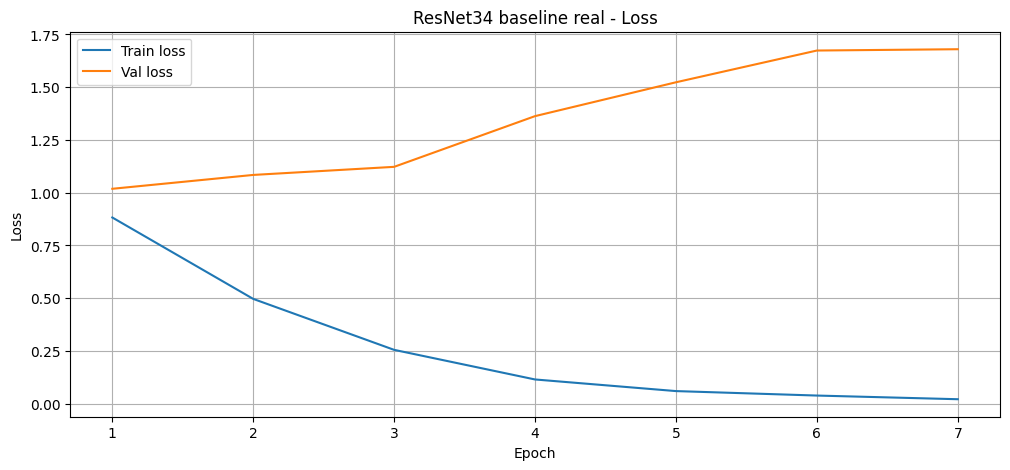

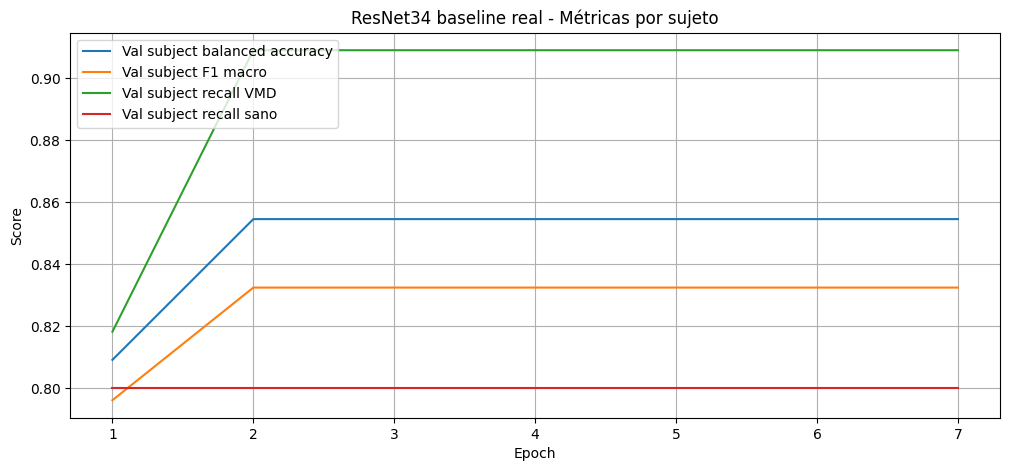

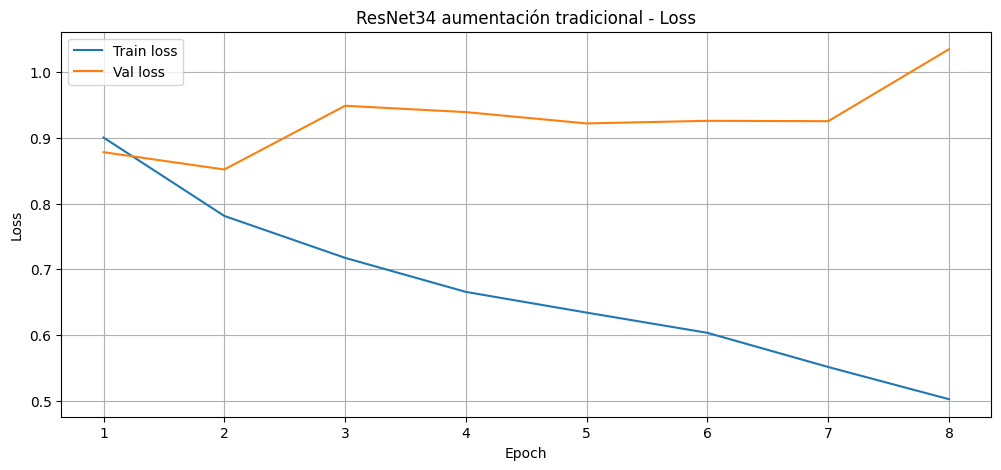

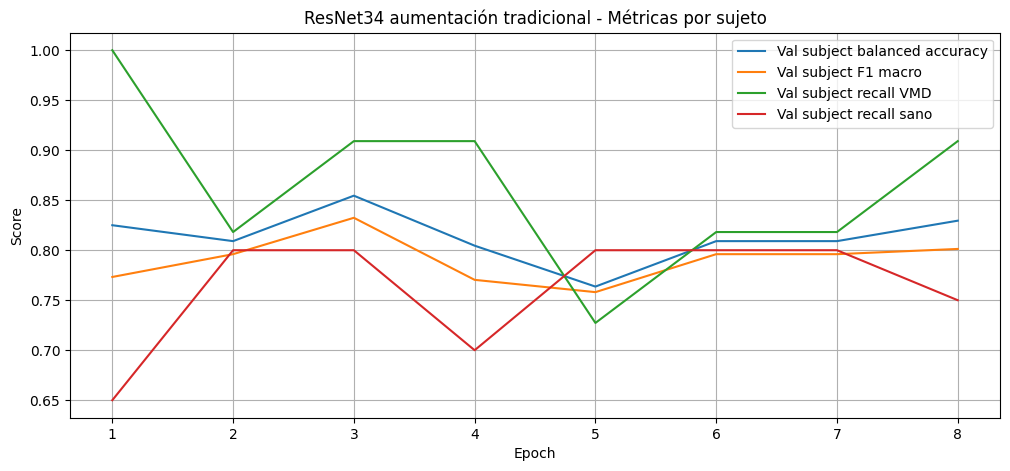

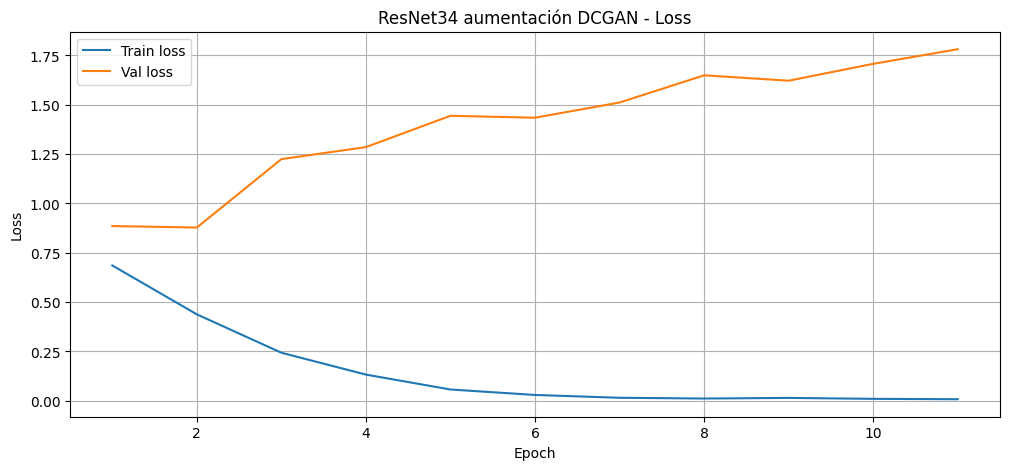

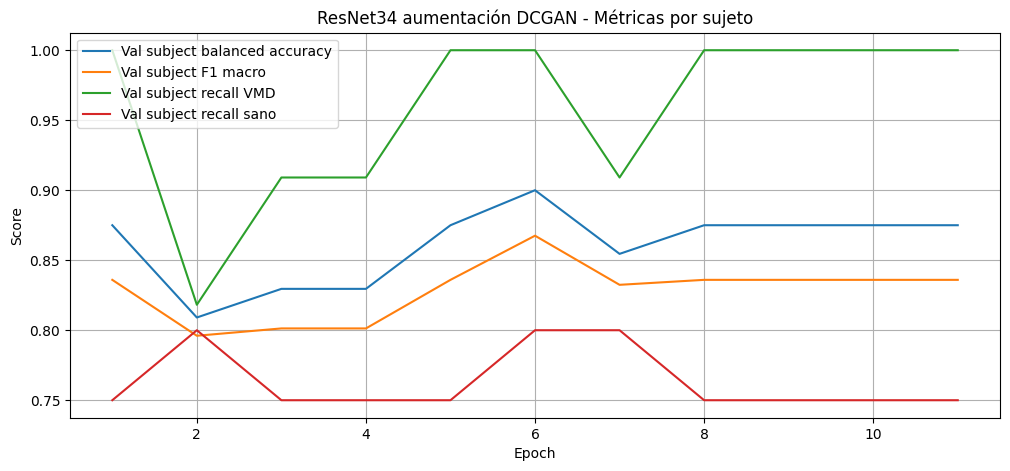

In [ ]:
# Historiales ResNet34

plot_training_history(
    resnet34_baseline_history,
    title="ResNet34 baseline real"
)

plot_training_history(
    resnet34_tradaug_history,
    title="ResNet34 aumentación tradicional"
)

plot_training_history(
    resnet34_dcgan_history,
    title="ResNet34 aumentación DCGAN"
)

## Sección 8 - Selección del mejor modelo y evaluación final en test

In [ ]:
# Seleccionar el mejor modelo en validación y evaluar en TEST


import scipy.stats as st

best_row = val_all_summary_df.loc[val_all_summary_df["f1_macro"].idxmax()]

print("=" * 60)
print("MEJOR MODELO (por F1-macro en VALIDACIÓN):")
print(f"  Modelo      : {best_row['model']}")
print(f"  Experimento : {best_row['experiment']}")
print(f"  F1-macro val: {best_row['f1_macro']:.4f}")
print(f"  Umbral ópt. : {best_row['optimal_threshold']:.2f}")
print("=" * 60)

_ckpt_map = {
    ("resnet18", "baseline_real"):   (os.path.join(OUTPUT_DIR, "best_baseline_real_resnet18.pth"),   baseline_val_loader,   baseline_test_loader),
    ("resnet18", "traditional_aug"): (os.path.join(OUTPUT_DIR, "best_traditional_aug_resnet18.pth"), traditional_val_loader, traditional_test_loader),
    ("resnet18", "dcgan_aug"):       (os.path.join(OUTPUT_DIR, "best_dcgan_aug_resnet18.pth"),       dcgan_val_loader,      dcgan_test_loader),
    ("resnet34", "baseline_real"):   (os.path.join(OUTPUT_DIR, "best_baseline_real_resnet34.pth"),   baseline_val_loader,   baseline_test_loader),
    ("resnet34", "traditional_aug"): (os.path.join(OUTPUT_DIR, "best_traditional_aug_resnet34.pth"), traditional_val_loader, traditional_test_loader),
    ("resnet34", "dcgan_aug"):       (os.path.join(OUTPUT_DIR, "best_dcgan_aug_resnet34.pth"),       dcgan_val_loader,      dcgan_test_loader),
}

best_key = (best_row["model"], best_row["experiment"])
best_ckpt_path, best_val_loader, best_test_loader = _ckpt_map[best_key]
best_label = f"{best_row['model']}_{best_row['experiment']}"

best_test_results = evaluate_checkpoint_on_test(
    checkpoint_path=best_ckpt_path,
    val_loader=best_val_loader,
    test_loader=best_test_loader,
    experiment_label=best_label,
)

N_BOOTSTRAP = 2000
CONFIDENCE   = 0.95
RANDOM_SEED_BS = 42

def bootstrap_metrics_subjects(subject_df, n_bootstrap=2000, confidence=0.95, seed=42):
    """
    Bootstrap con remuestreo de SUJETOS .
    Calcula IC para F1-macro, balanced_accuracy, recall_vmd, precision_vmd,
    specificity, AUC y MCC.
    """
    rng = np.random.default_rng(seed)
    n = len(subject_df)

    y_true = subject_df["label"].values.astype(int)
    y_pred = subject_df["pred"].values.astype(int)
    y_prob = subject_df["prob_vmd"].values

    metric_keys = [
        "f1_macro", "balanced_accuracy", "recall_vmd",
        "precision_vmd", "specificity", "auc", "mcc"
    ]
    boot_results = {k: [] for k in metric_keys}

    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)
        y_t = y_true[idx]
        y_p = y_pred[idx]
        y_pr = y_prob[idx]

        if len(np.unique(y_t)) < 2:
            continue

        m = compute_binary_metrics(y_t, y_p, y_pr)
        for k in metric_keys:
            boot_results[k].append(m[k])

    alpha = 1 - confidence
    ci_results = {}
    for k in metric_keys:
        vals = np.array(boot_results[k])
        vals = vals[~np.isnan(vals)]
        if len(vals) == 0:
            ci_results[k] = (np.nan, np.nan, np.nan)
        else:
            lo = np.percentile(vals, 100 * alpha / 2)
            hi = np.percentile(vals, 100 * (1 - alpha / 2))
            ci_results[k] = (np.mean(vals), lo, hi)

    return ci_results


print(f"\n{'=' * 60}")
print(f"BOOTSTRAP TEST — {best_label}  (n={N_BOOTSTRAP} réplicas, IC {int(CONFIDENCE*100)}%)")
print(f"{'=' * 60}")

subject_df_test = best_test_results["subject_predictions"]
ci = bootstrap_metrics_subjects(
    subject_df_test,
    n_bootstrap=N_BOOTSTRAP,
    confidence=CONFIDENCE,
    seed=RANDOM_SEED_BS
)

print(f"\n{'Métrica':<22} {'Media':>8}  {'IC lo':>8}  {'IC hi':>8}")
print("-" * 52)
for k, (mean_v, lo, hi) in ci.items():
    print(f"  {k:<20} {mean_v:>8.4f}  {lo:>8.4f}  {hi:>8.4f}")

# Guardar tabla bootstrap
ci_df = pd.DataFrame([
    {"metric": k, "mean": v[0], "ci_lo": v[1], "ci_hi": v[2]}
    for k, v in ci.items()
])
ci_path = os.path.join(OUTPUT_DIR, f"bootstrap_test_{best_label}.csv")
ci_df.to_csv(ci_path, index=False)
print(f"\nTabla bootstrap guardada en: {ci_path}")


MEJOR MODELO (por F1-macro en VALIDACIÓN):
  Modelo      : resnet18
  Experimento : dcgan_aug
  F1-macro val: 0.8675
  Umbral ópt. : 0.25
Resultados TEST - resnet18_dcgan_aug
Umbral óptimo: 0.25  (F1-macro val sujeto = 0.8675)

Métricas a nivel de SUJETO en TEST:
  Loss              : 0.7015
  Accuracy          : 0.7419
  Balanced Accuracy : 0.8095
  F1 Macro          : 0.7395
  F1 VMD            : 0.7143
  Precision VMD     : 0.5556
  Recall VMD        : 1.0000
  Specificity       : 0.6190
  MCC               : 0.5864
  AUC               : 0.9333

  Sujetos en test: 31  | cortes/sujeto min=10 max=10

Predicciones guardadas en:
  /content/drive/MyDrive/Proyecto imagenes y vision/OASIS_2D_Slices/classification_2d_outputs/predictions_test_resnet18_dcgan_aug.csv
  /content/drive/MyDrive/Proyecto imagenes y vision/OASIS_2D_Slices/classification_2d_outputs/predictions_test_subject_resnet18_dcgan_aug.csv

BOOTSTRAP TEST — resnet18_dcgan_aug  (n=2000 réplicas, IC 95%)

Métrica                

In [ ]:
def plot_subject_confusion_matrix(results, title, save_name=None):
    subject_df = results["subject_predictions"]

    y_true = subject_df["label"].values.astype(int)
    y_pred = subject_df["pred"].values.astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    print(f"{title}")
    print(f"  {'':12s}  Pred sano  Pred vmd")
    print(f"  {'Real sano':<12s}  {cm[0,0]:>9d}  {cm[0,1]:>8d}")
    print(f"  {'Real vmd':<12s}  {cm[1,0]:>9d}  {cm[1,1]:>8d}")
    print(f"  TP={tp}  FP={fp}  FN={fn}  TN={tn}")
    if (tp + fn) > 0:
        print(f"  Falsos negativos (VMD->sano): {fn}  "
              f"({100*fn/(tp+fn):.1f}% del total VMD)")
    print()

    plt.figure(figsize=(5, 4))
    plt.imshow(cm, cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.xticks([0, 1], ["sano", "vmd"])
    plt.yticks([0, 1], ["sano", "vmd"])

    thresh_color = cm.max() / 2.0
    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > thresh_color else "black",
                     fontweight="bold")

    plt.colorbar()
    plt.tight_layout()

    if save_name is not None:
        fig_path = os.path.join(OUTPUT_DIR, save_name)
        plt.savefig(fig_path, dpi=150, bbox_inches="tight")
        print(f"  Figura guardada en: {fig_path}")

    plt.show()

Matriz de confusión — TEST (resnet18_dcgan_aug)
                Pred sano  Pred vmd
  Real sano            13         8
  Real vmd              0        10
  TP=10  FP=8  FN=0  TN=13
  Falsos negativos (VMD->sano): 0  (0.0% del total VMD)

  Figura guardada en: /content/drive/MyDrive/Proyecto imagenes y vision/OASIS_2D_Slices/classification_2d_outputs/cm_best_resnet18_dcgan_aug.png


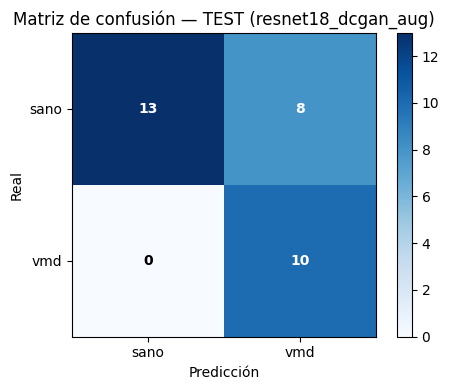

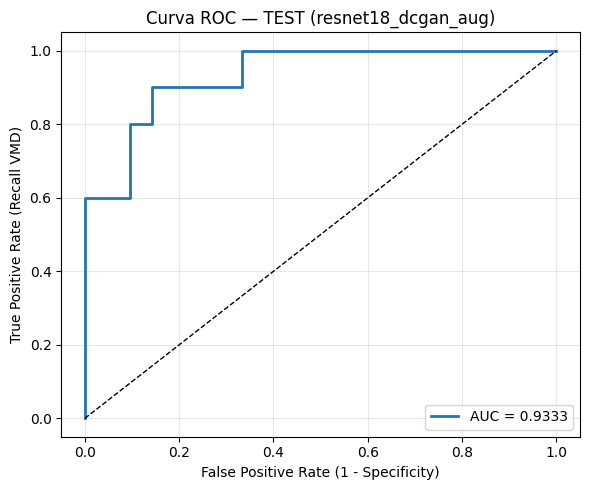

ROC guardada en: /content/drive/MyDrive/Proyecto imagenes y vision/OASIS_2D_Slices/classification_2d_outputs/roc_best_resnet18_dcgan_aug.png


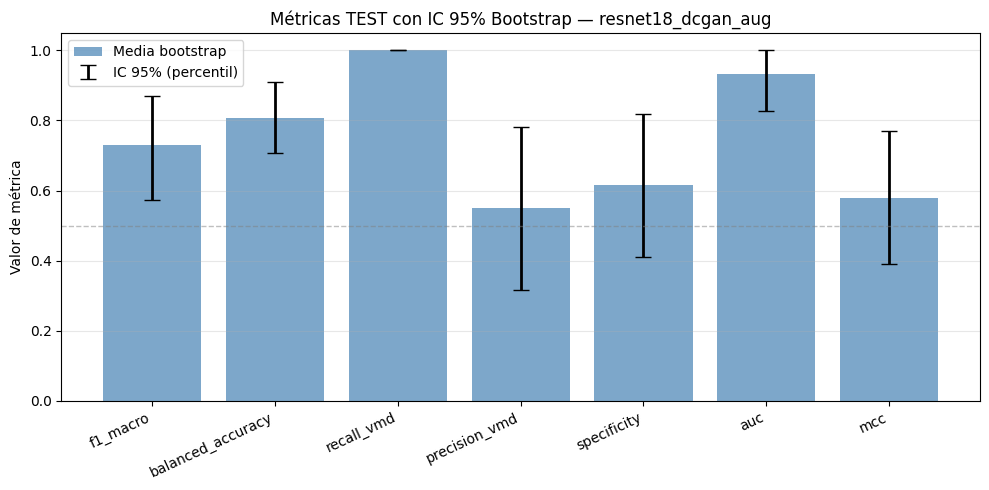

Gráfica bootstrap guardada en: /content/drive/MyDrive/Proyecto imagenes y vision/OASIS_2D_Slices/classification_2d_outputs/bootstrap_ic_resnet18_dcgan_aug.png


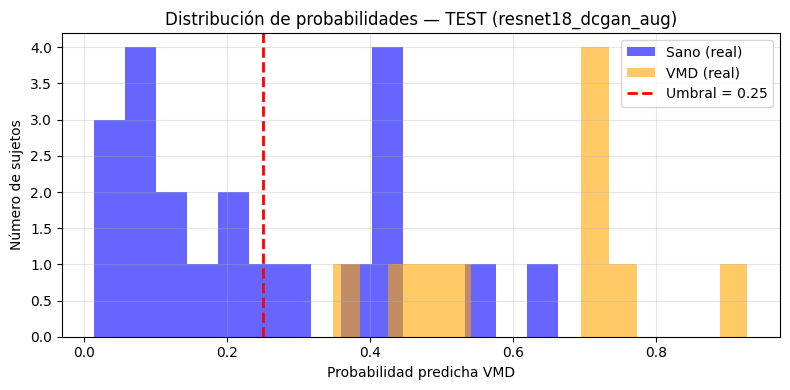

Distribución de probabilidades guardada en: /content/drive/MyDrive/Proyecto imagenes y vision/OASIS_2D_Slices/classification_2d_outputs/prob_dist_best_resnet18_dcgan_aug.png


In [ ]:
import matplotlib.patches as mpatches
from sklearn.metrics import roc_curve

fig_label = best_label

plot_subject_confusion_matrix(
    best_test_results,
    title=f"Matriz de confusión — TEST ({fig_label})",
    save_name=f"cm_best_{fig_label}.png"
)

subject_df_test = best_test_results["subject_predictions"]
y_true_test = subject_df_test["label"].values.astype(int)
y_prob_test  = subject_df_test["prob_vmd"].values

fpr, tpr, _ = roc_curve(y_true_test, y_prob_test)
auc_val = best_test_results["subject_metrics"]["auc"]

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, lw=2, label=f"AUC = {auc_val:.4f}")
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Recall VMD)")
plt.title(f"Curva ROC — TEST ({fig_label})")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
roc_path = os.path.join(OUTPUT_DIR, f"roc_best_{fig_label}.png")
plt.savefig(roc_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"ROC guardada en: {roc_path}")

ci_df_plot = ci_df.copy()
ci_df_plot["error_lo"] = ci_df_plot["mean"] - ci_df_plot["ci_lo"]
ci_df_plot["error_hi"] = ci_df_plot["ci_hi"] - ci_df_plot["mean"]

fig, ax = plt.subplots(figsize=(10, 5))

x_pos = np.arange(len(ci_df_plot))
ax.bar(x_pos, ci_df_plot["mean"], color="steelblue", alpha=0.7, label="Media bootstrap")
ax.errorbar(
    x_pos, ci_df_plot["mean"],
    yerr=[ci_df_plot["error_lo"].values, ci_df_plot["error_hi"].values],
    fmt="none", color="black", capsize=6, linewidth=2,
    label=f"IC {int(CONFIDENCE*100)}% (percentil)"
)

ax.set_xticks(x_pos)
ax.set_xticklabels(ci_df_plot["metric"], rotation=25, ha="right")
ax.set_ylabel("Valor de métrica")
ax.set_title(f"Métricas TEST con IC {int(CONFIDENCE*100)}% Bootstrap — {fig_label}")
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color="gray", lw=1, linestyle="--", alpha=0.5)
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()

boot_fig_path = os.path.join(OUTPUT_DIR, f"bootstrap_ic_{fig_label}.png")
plt.savefig(boot_fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Gráfica bootstrap guardada en: {boot_fig_path}")

plt.figure(figsize=(8, 4))
sano_probs = subject_df_test[subject_df_test["label"] == 0]["prob_vmd"].values
vmd_probs  = subject_df_test[subject_df_test["label"] == 1]["prob_vmd"].values

plt.hist(sano_probs, bins=15, alpha=0.6, color="blue",   label="Sano (real)")
plt.hist(vmd_probs,  bins=15, alpha=0.6, color="orange", label="VMD (real)")
plt.axvline(best_test_results["optimal_threshold"], color="red", lw=2,
            linestyle="--", label=f"Umbral = {best_test_results['optimal_threshold']:.2f}")
plt.xlabel("Probabilidad predicha VMD")
plt.ylabel("Número de sujetos")
plt.title(f"Distribución de probabilidades — TEST ({fig_label})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
prob_path = os.path.join(OUTPUT_DIR, f"prob_dist_best_{fig_label}.png")
plt.savefig(prob_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Distribución de probabilidades guardada en: {prob_path}")

## Sección 9 - Comparación final de experimentos e incertidumbre estadística

In [ ]:
import os
import numpy as np
import pandas as pd

experiments = [
    ("resnet18", "baseline_real"),
    ("resnet18", "traditional_aug"),
    ("resnet18", "dcgan_aug"),
    ("resnet34", "baseline_real"),
    ("resnet34", "traditional_aug"),
    ("resnet34", "dcgan_aug"),
]

def get_n_params(model_name):
    m = create_resnet_binary(model_name=model_name, pretrained=False)
    n = sum(p.numel() for p in m.parameters()) / 1e6
    del m
    return round(n, 2)

n_params_cache = {
    "resnet18": get_n_params("resnet18"),
    "resnet34": get_n_params("resnet34"),
}

cost_rows = []

for model_name, exp_name in experiments:
    history_path = os.path.join(OUTPUT_DIR, f"history_{exp_name}_{model_name}.csv")
    if os.path.exists(history_path):
        hist = pd.read_csv(history_path)
        epochs = len(hist)
        times  = hist["epoch_time_sec"].values

        # T. total: suma de todas las épocas (incluye descarga si ocurrió)
        total_time_min = round(times.sum() / 60.0, 1)

        # T. época: suma excluyendo outliers de descarga de pesos
        median_t     = np.median(times)
        times_normal = times[times <= 10 * median_t]
        sum_epoch_s  = round(times_normal.sum(), 1)

        cost_rows.append({
            "Modelo":         model_name,
            "Escenario":      exp_name,
            "Épocas":         epochs,
            "T. total (min)": total_time_min,
            "T. épocas (s)":   sum_epoch_s,
            "Parámetros (M)": n_params_cache[model_name],
        })
    else:
        print(f"No encontrado: {history_path}")

cost_df = pd.DataFrame(cost_rows)
print("=== Resumen computacional 2D ===")
display(cost_df)

cost_df.to_csv(os.path.join(OUTPUT_DIR, "cost_summary_2d.csv"), index=False)

=== Resumen computacional 2D ===


,Modelo,Escenario,Épocas,T. total (min),T. épocas (s),Parámetros (M)
0,resnet18,baseline_real,9,9.9,30.2,11.18
1,resnet18,traditional_aug,12,0.9,51.7,11.18
2,resnet18,dcgan_aug,12,3.8,54.7,11.18
3,resnet34,baseline_real,7,0.5,29.3,21.29
4,resnet34,traditional_aug,8,0.6,35.2,21.29
5,resnet34,dcgan_aug,11,1.0,57.2,21.29


In [ ]:
val_all_summary_df = pd.read_csv(os.path.join(OUTPUT_DIR, "val_summary_all.csv"))
best_row   = val_all_summary_df.loc[val_all_summary_df["f1_macro"].idxmax()]
best_label = f"{best_row['model']}_{best_row['experiment']}"

ci_df = pd.read_csv(os.path.join(OUTPUT_DIR, f"bootstrap_test_{best_label}.csv"))

print(f"Bootstrap TEST — {best_label}  (val F1-macro = {best_row['f1_macro']:.4f})")
print(f"\n{'Métrica':<22} {'Media':>8}  {'IC lo':>8}  {'IC hi':>8}")
print("-" * 52)
for _, row in ci_df.iterrows():
    print(f"  {row['metric']:<20} {row['mean']:>8.4f}  {row['ci_lo']:>8.4f}  {row['ci_hi']:>8.4f}")

Bootstrap TEST — resnet18_dcgan_aug  (val F1-macro = 0.8675)

Métrica                   Media     IC lo     IC hi
----------------------------------------------------
  f1_macro               0.7299    0.5735    0.8708
  balanced_accuracy      0.8076    0.7059    0.9091
  recall_vmd             1.0000    1.0000    1.0000
  precision_vmd          0.5514    0.3158    0.7826
  specificity            0.6151    0.4118    0.8182
  auc                    0.9334    0.8261    1.0000
  mcc                    0.5797    0.3893    0.7712
